# Task 1 - Step 5: Clean baseline, colour, shape vs texture, translation, patch shuffle

Manual Steps 1-5, evaluated on the saved outputs of notebook 04, so every analysis uses identical
predictions. Four systems: ResNet-50 + head, ViT-B/16 + head, CLIP + head, CLIP zero-shot.

Every intervention is reported as an absolute number **and** relative to the same system's clean
baseline. *Prediction consistency* = fraction of images whose predicted class is unchanged relative
to the clean image.

In [1]:
# ---- Common header (identical in every Task 1 notebook) ----
import json, random, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

# Locate the task1/ folder no matter where Jupyter was launched from.
ROOT = Path.cwd()
if not (ROOT / "configs").exists() and (ROOT / "task1" / "configs").exists():
    ROOT = ROOT / "task1"

CFG = json.loads((ROOT / "configs" / "task1_config.json").read_text())
SEED = CFG["seed"]

# Small, git-tracked outputs -> results/.  Large tensors/weights/raw data -> cache/ and data/ (git-ignored).
RES = ROOT / "results"
CACHE = ROOT / "cache"
DATA = ROOT / "data"
for p in [RES / "subset", RES / "cue_conflicts", RES / "tables", RES / "figures",
          CACHE / "sets", CACHE / "features", CACHE / "heads", CACHE / "weights", DATA]:
    p.mkdir(parents=True, exist_ok=True)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"


def set_seed(seed=SEED):
    """Fix every RNG we use so reruns reproduce the same numbers."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


set_seed()
print("ROOT:", ROOT, "| device:", DEVICE, "| seed:", SEED)

ROOT: C:\Users\afifh\Desktop\ATML\PA1\task1 | device: cuda | seed: 6304


In [2]:
from sklearn.metrics import f1_score

plt.rcParams.update({"font.size": 11, "axes.titlesize": 12, "axes.labelsize": 11, "legend.fontsize": 9,
                     "figure.dpi": 100, "savefig.dpi": 150})
TAB, FIG = RES / "tables", RES / "figures"


def savefig(fig, stem):
    """Save every figure as PNG + PDF under results/figures (never only displayed)."""
    fig.savefig(FIG / f"{stem}.png", bbox_inches="tight")
    fig.savefig(FIG / f"{stem}.pdf", bbox_inches="tight")
    print("saved figure", stem)

B = torch.load(CACHE / "outputs" / "task1_outputs.pt")
CLASSES, SYSTEMS, P = B["classes"], B["systems"], B["probs"]
y = B["labels"].numpy()
if B["smoke"]:
    print("WARNING: these are SMOKE-mode outputs - do not report these numbers")


def pred(system, name):
    return P[system][name].argmax(1).numpy()


def per_class_acc(yhat, ytrue):
    return {c: float((yhat[ytrue == k] == k).mean()) for k, c in enumerate(CLASSES) if (ytrue == k).any()}


def summary(system, name, ytrue):
    p = P[system][name]; yhat = p.argmax(1).numpy()
    return {"top1_acc": float((yhat == ytrue).mean()), "macro_f1": float(f1_score(ytrue, yhat, average="macro")),
            "mean_max_conf": float(p.max(1).values.mean()), "n": int(len(ytrue))}

## 5.1 Clean baseline

Top-1 accuracy, macro-F1 and mean maximum confidence on the 500-image class-balanced test subset.

In [3]:
CLEAN = {s: {**summary(s, "clean", y), "per_class_accuracy": per_class_acc(pred(s, "clean"), y)} for s in SYSTEMS}
(TAB / "task1_clean_metrics.json").write_text(json.dumps({"n_images": int(len(y)), "metrics": CLEAN}, indent=1))
pd.DataFrame({s: {k: v for k, v in m.items() if k != "per_class_accuracy"} for s, m in CLEAN.items()}).T

,top1_acc,macro_f1,mean_max_conf,n
resnet50_head,0.970,0.969991,0.915879,500.0
vit_b16_head,0.968,0.968086,0.964636,500.0
clip_head,0.968,0.967958,0.141713,500.0
clip_zeroshot,0.936,0.935546,0.924622,500.0


In [4]:
pd.DataFrame({s: m["per_class_accuracy"] for s, m in CLEAN.items()}).round(3)

,resnet50_head,vit_b16_head,clip_head,clip_zeroshot
airplane,0.96,0.96,0.98,0.96
bird,0.98,0.96,1.00,1.00
car,0.98,0.98,0.98,0.96
cat,0.92,0.98,0.92,0.74
deer,0.96,0.96,0.98,0.98
dog,0.96,0.96,0.92,0.82
horse,0.96,0.92,0.98,0.96
monkey,0.98,0.98,0.98,0.96
ship,1.00,1.00,1.00,1.00
truck,1.00,0.98,0.94,0.98


## 5.2 Colour (grayscale + hue rotation) and 5.5 patch shuffle

Same metric set for all three: accuracy, macro-F1, confidence, change vs clean, prediction
consistency, per-class accuracy. For patch shuffle we also measure **confident errors** (wrong
predictions with confidence >= 0.9) and how concentrated the predicted-class histogram becomes, because
a confident prediction after shuffling is not necessarily a sensible one.

In [5]:
def intervention_metrics(name):
    out = {}
    for s in SYSTEMS:
        m = summary(s, name, y)
        yhat, p = pred(s, name), P[s][name]
        m.update({
            "delta_acc_vs_clean": m["top1_acc"] - CLEAN[s]["top1_acc"],
            "delta_macro_f1_vs_clean": m["macro_f1"] - CLEAN[s]["macro_f1"],
            "delta_conf_vs_clean": m["mean_max_conf"] - CLEAN[s]["mean_max_conf"],
            "consistency": float((yhat == pred(s, "clean")).mean()),
            "per_class_accuracy": per_class_acc(yhat, y),
        })
        wrong = yhat != y
        conf = p.max(1).values.numpy()
        m["frac_confident_errors_ge_0.9"] = float((wrong & (conf >= 0.9)).mean())
        m["mean_conf_on_errors"] = float(conf[wrong].mean()) if wrong.any() else None
        m["predicted_class_histogram"] = {c: int((yhat == k).sum()) for k, c in enumerate(CLASSES)}
        out[s] = m
    return out


INTERV = {name: intervention_metrics(name) for name in ["grayscale", "hue_rotate", "patch_shuffle"]}
for name, fname in [("grayscale", "task1_grayscale_metrics.json"), ("hue_rotate", "task1_hue_metrics.json"),
                    ("patch_shuffle", "task1_patchshuffle_metrics.json")]:
    (TAB / fname).write_text(json.dumps({"intervention": name, "metrics": INTERV[name]}, indent=1))

rows = []
for s in SYSTEMS:
    rows.append({"system": s, "condition": "clean", **{k: CLEAN[s][k] for k in ["top1_acc", "macro_f1", "mean_max_conf"]},
                 "delta_acc_vs_clean": 0.0, "consistency": 1.0})
    for name in INTERV:
        m = INTERV[name][s]
        rows.append({"system": s, "condition": name, **{k: m[k] for k in
                     ["top1_acc", "macro_f1", "mean_max_conf", "delta_acc_vs_clean", "consistency"]}})
COMP = pd.DataFrame(rows)
COMP.to_csv(TAB / "task1_intervention_comparison.csv", index=False)
COMP.round(4)

,system,condition,top1_acc,macro_f1,mean_max_conf,delta_acc_vs_clean,consistency
0,resnet50_head,clean,0.970,0.9700,0.9159,0.000,1.000
1,resnet50_head,grayscale,0.948,0.9483,0.9183,-0.022,0.952
2,resnet50_head,hue_rotate,0.940,0.9400,0.9175,-0.030,0.948
3,resnet50_head,patch_shuffle,0.886,0.8870,0.8762,-0.084,0.894
4,vit_b16_head,clean,0.968,0.9681,0.9646,0.000,1.000
5,vit_b16_head,grayscale,0.946,0.9463,0.9542,-0.022,0.976
6,vit_b16_head,hue_rotate,0.932,0.9322,0.9364,-0.036,0.958
7,vit_b16_head,patch_shuffle,0.914,0.9151,0.8955,-0.054,0.938
8,clip_head,clean,0.968,0.9680,0.1417,0.000,1.000
9,clip_head,grayscale,0.928,0.9279,0.1378,-0.040,0.938


In [6]:
pc = []
for s in SYSTEMS:
    for cond, per in [("clean", CLEAN[s]["per_class_accuracy"])] + [(n, INTERV[n][s]["per_class_accuracy"]) for n in INTERV]:
        pc += [{"system": s, "condition": cond, "class": c, "accuracy": a} for c, a in per.items()]
pd.DataFrame(pc).to_csv(TAB / "task1_per_class_accuracy.csv", index=False)
pd.DataFrame(pc).pivot_table(index=["condition", "class"], columns="system", values="accuracy").round(2)

system                  clip_head  clip_zeroshot  resnet50_head  vit_b16_head
condition     class                                                          
clean         airplane       0.98           0.96           0.96          0.96
              bird           1.00           1.00           0.98          0.96
              car            0.98           0.96           0.98          0.98
              cat            0.92           0.74           0.92          0.98
              deer           0.98           0.98           0.96          0.96
              dog            0.92           0.82           0.96          0.96
              horse          0.98           0.96           0.96          0.92
              monkey         0.98           0.96           0.98          0.98
              ship           1.00           1.00           1.00          1.00
              truck          0.94           0.98           1.00          0.98
grayscale     airplane       0.98           0.96           0.94          0.92
              bird           0.96           0.98           0.92          0.96
              car            0.98           0.98           0.98          0.96
              cat            0.92           0.74           0.94          0.98
              deer           0.96           0.96           0.96          0.96
              dog            0.80           0.70           0.90          0.88
              horse          0.92           0.98           0.96          0.90
              monkey         0.88           0.86           0.92          0.96
              ship           0.94           0.98           0.98          0.96
              truck          0.94           0.94           0.98          0.98
hue_rotate    airplane       0.98           0.90           0.98          0.96
              bird           0.98           0.98           0.98          0.98
              car            0.98           1.00           0.98          0.98
              cat            0.82           0.70           0.94          0.92
              deer           0.96           0.98           0.96          0.96
              dog            0.82           0.76           0.86          0.84
              horse          0.92           1.00           0.86          0.82
              monkey         0.84           0.90           0.90          0.92
              ship           1.00           1.00           0.98          0.98
              truck          0.88           0.94           0.96          0.96
patch_shuffle airplane       0.94           0.74           0.90          0.98
              bird           1.00           1.00           0.98          0.94
              car            0.88           0.96           0.96          0.92
              cat            0.66           0.52           0.76          0.86
              deer           0.76           0.72           0.96          0.92
              dog            0.66           0.74           0.74          0.84
              horse          0.64           0.84           0.86          0.82
              monkey         0.80           0.66           0.84          0.96
              ship           0.74           0.92           0.96          0.96
              truck          0.88           0.88           0.90          0.94

saved figure task1_intervention_comparison


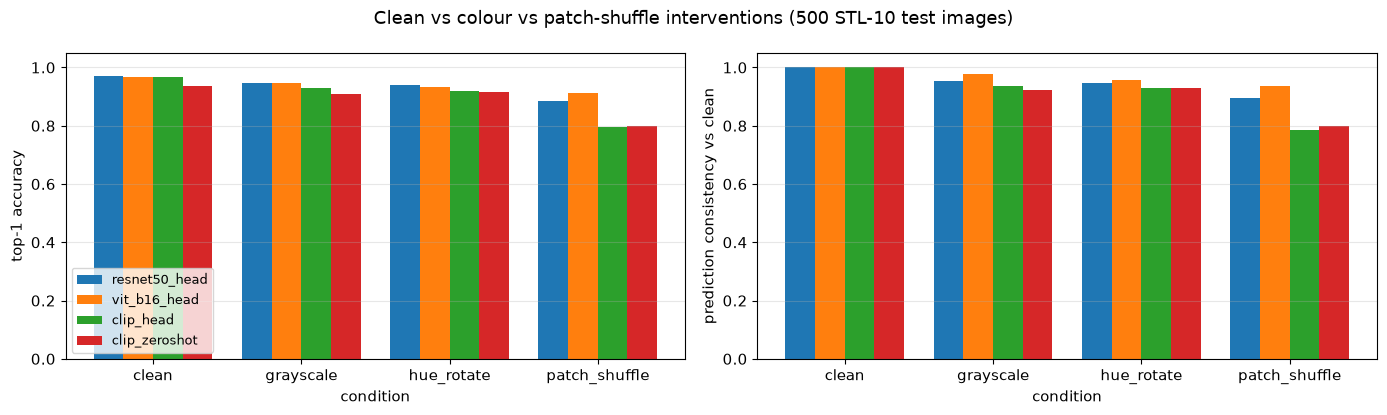

In [7]:
conds = ["clean", "grayscale", "hue_rotate", "patch_shuffle"]
fig, axes = plt.subplots(1, 2, figsize=(14, 4.2))
w = 0.2
for ax, metric, ylab in [(axes[0], "top1_acc", "top-1 accuracy"), (axes[1], "consistency", "prediction consistency vs clean")]:
    for i, s in enumerate(SYSTEMS):
        vals = [COMP[(COMP.system == s) & (COMP.condition == c)][metric].item() for c in conds]
        ax.bar(np.arange(len(conds)) + (i - 1.5) * w, vals, w, label=s)
    ax.set_xticks(np.arange(len(conds))); ax.set_xticklabels(conds); ax.set_ylim(0, 1.05)
    ax.set_ylabel(ylab); ax.set_xlabel("condition"); ax.grid(axis="y", alpha=.3)
axes[0].legend(loc="lower left")
fig.suptitle("Clean vs colour vs patch-shuffle interventions (500 STL-10 test images)")
plt.tight_layout(); savefig(fig, "task1_intervention_comparison"); plt.show()

## 5.3 Shape vs. texture (cue conflicts)

Each prediction on a retained conflict is **shape** (= content label), **texture** (= style label)
or **other**. Shape bias ignores "other", so it is always reported together with coverage:

`Shape Bias (%) = 100 * N_shape / (N_shape + N_texture)`, `Coverage (%) = 100 * (N_shape + N_texture) / N_total`.

Accepted/rejected counts come from the model-free rule of notebook 03.

In [8]:
cc = B["cue_conflict"]
sh, tx = cc["shape_label"].numpy(), cc["texture_label"].numpy()
meta = pd.read_csv(RES / "cue_conflicts" / "metadata.csv")
kept = meta[meta["keep"]].reset_index(drop=True)            # same order as cue_conflict.pt (notebook 03)
assert len(kept) == len(sh) and (kept.shape_label.values == sh).all() and (kept.texture_label.values == tx).all()
ACCEPT = pd.read_csv(TAB / "cue_conflict_acceptance.csv")
print(ACCEPT.to_string(index=False))
print("retained conflicts:", len(sh))


def sb_row(system, scope, cat):
    ns, nt, no = int((cat == "shape").sum()), int((cat == "texture").sum()), int((cat == "other").sum())
    n = ns + nt + no
    return {"system": system, "scope": scope, "n_total": n, "n_shape": ns, "n_texture": nt, "n_other": no,
            "shape_bias_pct": 100 * ns / (ns + nt) if ns + nt else None,
            "coverage_pct": 100 * (ns + nt) / n if n else None}


SB, CATS = [], {}
for s in SYSTEMS:
    yhat = pred(s, "cue_conflict")
    cat = np.where(yhat == sh, "shape", np.where(yhat == tx, "texture", "other"))
    CATS[s] = cat
    SB.append(sb_row(s, "all", cat))
    for pair, g in kept.groupby("pair"):
        SB.append(sb_row(s, f"pair={pair}", cat[g.index]))
    for (pair, d), g in kept.groupby(["pair", "direction"]):
        SB.append(sb_row(s, f"cell={kept.loc[g.index[0], 'shape_class']}(shape)/{kept.loc[g.index[0], 'texture_class']}(texture)",
                         cat[g.index]))
SB = pd.DataFrame(SB)
SB.to_csv(TAB / "task1_shape_texture_results.csv", index=False)
SB[SB.scope == "all"].round(2)

          pair         direction  generated  accepted  kept  rejected
airplane/horse A_shape_B_texture         40        40    25         0
airplane/horse B_shape_A_texture         40        37    25         3
      bird/car A_shape_B_texture         40        39    25         1
      bird/car B_shape_A_texture         40        39    25         1
      cat/ship A_shape_B_texture         40        40    25         0
      cat/ship B_shape_A_texture         40        39    25         1
    deer/truck A_shape_B_texture         40        39    25         1
    deer/truck B_shape_A_texture         40        39    25         1
    dog/monkey A_shape_B_texture         40        38    25         2
    dog/monkey B_shape_A_texture         40        39    25         1
retained conflicts: 250


,system,scope,n_total,n_shape,n_texture,n_other,shape_bias_pct,coverage_pct
0,resnet50_head,all,250,70,62,118,53.03,52.8
16,vit_b16_head,all,250,104,36,110,74.29,56.0
32,clip_head,all,250,125,16,109,88.65,56.4
48,clip_zeroshot,all,250,120,17,113,87.59,54.8


In [9]:
SB[SB.scope.str.startswith("pair=")].pivot_table(index="scope", columns="system", values=["shape_bias_pct", "coverage_pct"]).round(1)

coverage_pct                                           \
system                 clip_head clip_zeroshot resnet50_head vit_b16_head   
scope                                                                       
pair=airplane/horse         32.0          28.0          18.0         54.0   
pair=bird/car               90.0          94.0          84.0         72.0   
pair=cat/ship               24.0          44.0          46.0         38.0   
pair=deer/truck             64.0          42.0          54.0         38.0   
pair=dog/monkey             72.0          66.0          62.0         78.0   

                    shape_bias_pct                                           
system                   clip_head clip_zeroshot resnet50_head vit_b16_head  
scope                                                                        
pair=airplane/horse           81.2          78.6          33.3         48.1  
pair=bird/car                 91.1          91.5          50.0         88.9  
pair=cat/ship                 91.7          68.2          21.7         52.6  
pair=deer/truck               93.8         100.0          40.7         84.2  
pair=dog/monkey               83.3          90.9          96.8         84.6

saved figure task1_shape_bias_coverage


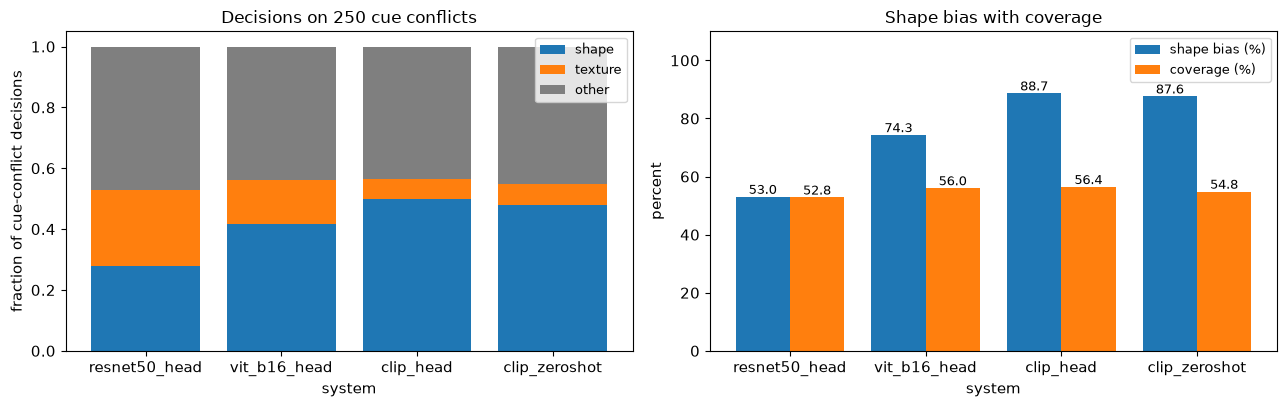

In [10]:
allrows = SB[SB.scope == "all"].set_index("system").loc[SYSTEMS]
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
bottom = np.zeros(len(SYSTEMS))
for key, col in [("n_shape", "tab:blue"), ("n_texture", "tab:orange"), ("n_other", "tab:gray")]:
    frac = allrows[key].values / allrows["n_total"].values
    axes[0].bar(SYSTEMS, frac, bottom=bottom, color=col, label=key.replace("n_", ""))
    bottom += frac
axes[0].set_ylabel("fraction of cue-conflict decisions"); axes[0].set_xlabel("system")
axes[0].legend(loc="upper right"); axes[0].set_title(f"Decisions on {int(allrows.n_total.iloc[0])} cue conflicts")
x = np.arange(len(SYSTEMS))
axes[1].bar(x - .2, allrows.shape_bias_pct.values, .4, label="shape bias (%)")
axes[1].bar(x + .2, allrows.coverage_pct.values, .4, label="coverage (%)")
for i, (b, c) in enumerate(zip(allrows.shape_bias_pct.values, allrows.coverage_pct.values)):
    axes[1].text(i - .2, b + 1, f"{b:.1f}", ha="center", fontsize=9); axes[1].text(i + .2, c + 1, f"{c:.1f}", ha="center", fontsize=9)
axes[1].set_xticks(x); axes[1].set_xticklabels(SYSTEMS); axes[1].set_ylim(0, 110)
axes[1].set_ylabel("percent"); axes[1].set_xlabel("system"); axes[1].legend(); axes[1].set_title("Shape bias with coverage")
plt.tight_layout(); savefig(fig, "task1_shape_bias_coverage"); plt.show()

## 5.4 Translation (0, 8, 16, 32 px x 4 directions, reflection padding + shifted crop)

At displacement 0 the image is the clean image, so accuracy = clean accuracy and consistency = 1.
Results are reported per direction and averaged over the four directions.

In [11]:
tr = CFG["translation"]
rows = []
for s in SYSTEMS:
    for d in tr["directions"]:
        rows.append({"system": s, "displacement_px": 0, "direction": d, "top1_acc": CLEAN[s]["top1_acc"], "consistency": 1.0})
        for delta in tr["displacements"]:
            name = f"translate_{d}_{delta}"
            rows.append({"system": s, "displacement_px": delta, "direction": d,
                         "top1_acc": float((pred(s, name) == y).mean()),
                         "consistency": float((pred(s, name) == pred(s, "clean")).mean())})
TR = pd.DataFrame(rows)
TR_MEAN = (TR.groupby(["system", "displacement_px"]).agg(top1_acc=("top1_acc", "mean"), top1_acc_std=("top1_acc", "std"),
           consistency=("consistency", "mean"), consistency_std=("consistency", "std")).reset_index().assign(direction="mean"))
pd.concat([TR, TR_MEAN]).to_csv(TAB / "task1_translation_results.csv", index=False)
TR_MEAN.pivot(index="displacement_px", columns="system", values=["top1_acc", "consistency"]).round(4)

top1_acc                                           \
system          clip_head clip_zeroshot resnet50_head vit_b16_head   
displacement_px                                                      
0                  0.9680        0.9360         0.970       0.9680   
8                  0.9605        0.9475         0.964       0.9710   
16                 0.9555        0.9420         0.963       0.9665   
32                 0.9455        0.9275         0.957       0.9630   

                consistency                                           
system            clip_head clip_zeroshot resnet50_head vit_b16_head  
displacement_px                                                       
0                    1.0000        1.0000        1.0000       1.0000  
8                    0.9685        0.9595        0.9865       0.9850  
16                   0.9615        0.9550        0.9885       0.9915  
32                   0.9575        0.9640        0.9780       0.9875

saved figure task1_translation_curve


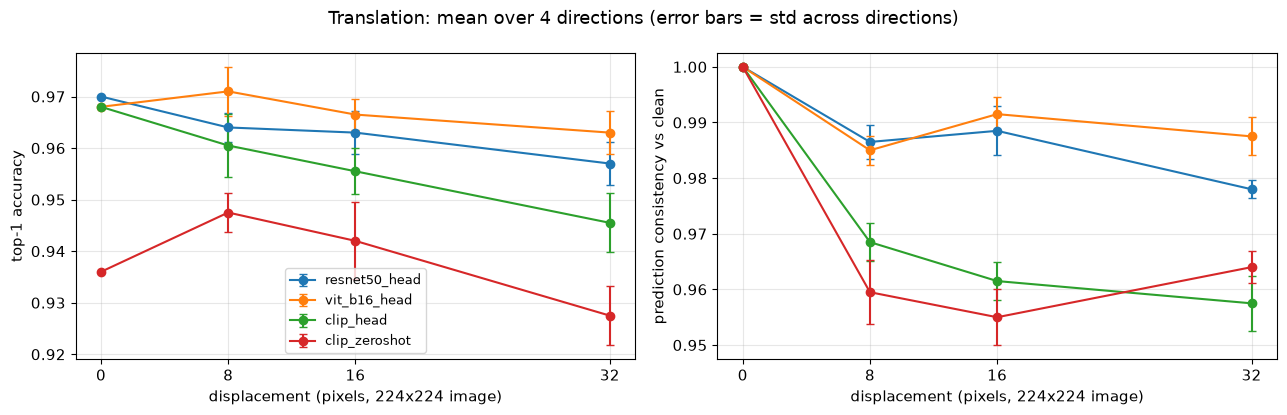

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
for s in SYSTEMS:
    g = TR_MEAN[TR_MEAN.system == s]
    for ax, m in zip(axes, ["top1_acc", "consistency"]):
        ax.errorbar(g.displacement_px, g[m], yerr=g[m + "_std"], marker="o", capsize=3, label=s)
for ax, lab in zip(axes, ["top-1 accuracy", "prediction consistency vs clean"]):
    ax.set_xlabel("displacement (pixels, 224x224 image)"); ax.set_ylabel(lab); ax.set_xticks([0] + tr["displacements"])
    ax.grid(alpha=.3)
axes[0].legend()
fig.suptitle("Translation: mean over 4 directions (error bars = std across directions)")
plt.tight_layout(); savefig(fig, "task1_translation_curve"); plt.show()

## 5.5 Patch shuffle summary

In [13]:
pd.DataFrame({s: {k: INTERV["patch_shuffle"][s][k] for k in ["top1_acc", "delta_acc_vs_clean", "consistency", "mean_max_conf",
              "delta_conf_vs_clean", "frac_confident_errors_ge_0.9", "mean_conf_on_errors"]} for s in SYSTEMS}).T.round(4)

,top1_acc,delta_acc_vs_clean,consistency,mean_max_conf,delta_conf_vs_clean,frac_confident_errors_ge_0.9,mean_conf_on_errors
resnet50_head,0.886,-0.084,0.894,0.8762,-0.0397,0.014,0.6628
vit_b16_head,0.914,-0.054,0.938,0.8955,-0.0691,0.018,0.7057
clip_head,0.796,-0.172,0.786,0.1230,-0.0187,0.000,0.1142
clip_zeroshot,0.798,-0.138,0.798,0.7693,-0.1553,0.012,0.5518


In [14]:
pd.DataFrame({s: INTERV["patch_shuffle"][s]["predicted_class_histogram"] for s in SYSTEMS})

,resnet50_head,vit_b16_head,clip_head,clip_zeroshot
airplane,46,52,61,39
bird,51,48,79,88
car,51,46,46,55
cat,48,47,40,29
deer,70,64,50,44
dog,42,47,41,46
horse,48,44,36,53
monkey,43,50,59,47
ship,54,51,37,53
truck,47,51,51,46
